<a href="https://colab.research.google.com/github/moribir-collab/SDS210-Birle/blob/main/Project_Birle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
14 Raster-Data found.
  - LandsatComposite_Zurich_1985.tif
  - LandsatComposite_Zurich_1988.tif
  - LandsatComposite_Zurich_1991.tif
  - ... and 11 more
Datei:   LandsatComposite_Zurich_1985.tif
CRS:     EPSG:32632
Bänder:  7
Shape:   (252, 297)
Bounds:  BoundingBox(left=459960.0, bottom=5245110.0, right=468870.0, top=5252670.0)

Band 1: min=0.0151, max=0.2113, mean=0.0510
Band 2: min=0.0273, max=0.2724, mean=0.0756
Band 3: min=0.0196, max=0.2955, mean=0.0722
Band 4: min=0.0305, max=0.5499, mean=0.2504
Band 5: min=0.0032, max=0.4813, mean=0.1724
Band 6: min=-0.0008, max=0.4880, mean=0.1137
Band 7: min=292.0322, max=318.8858, mean=301.9350


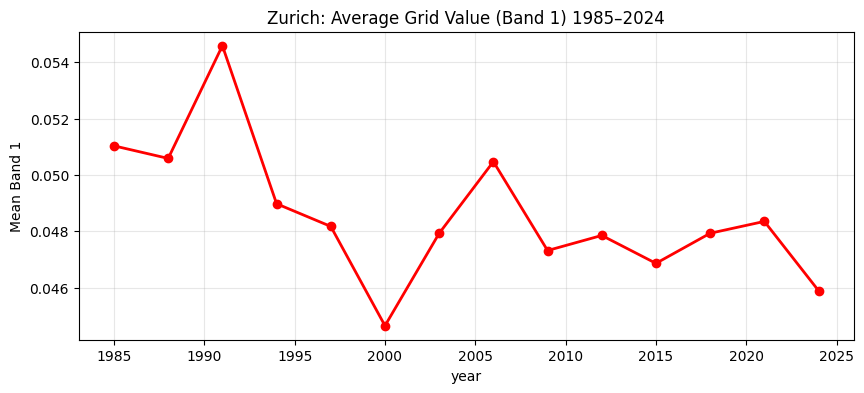

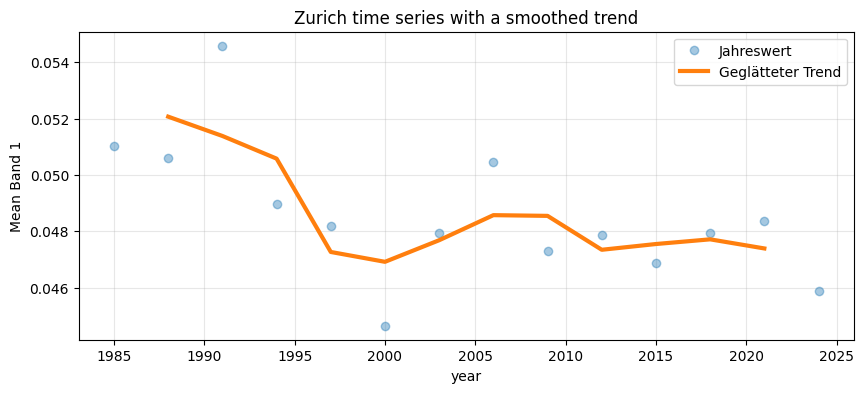

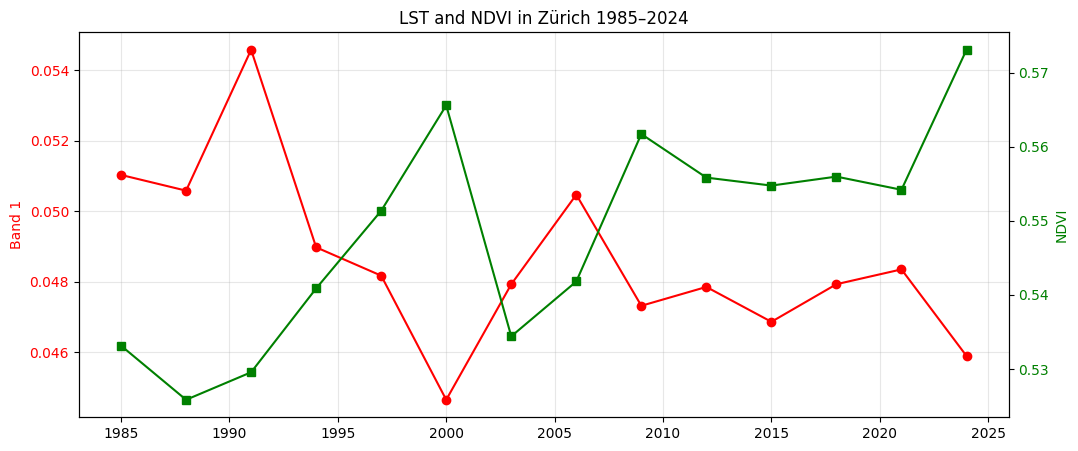

Pearson-Korrelation LST vs NDVI: r = -0.8221


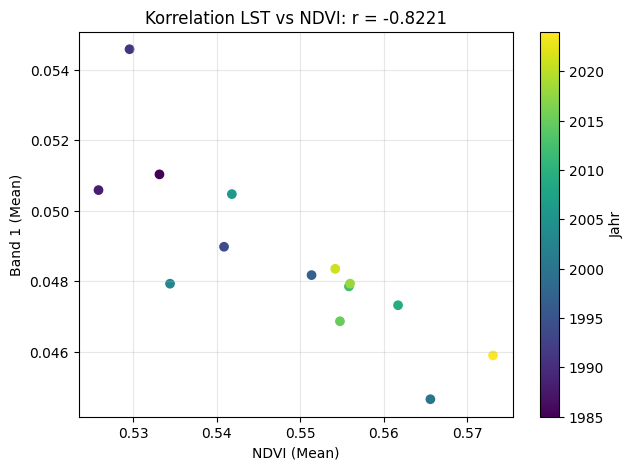

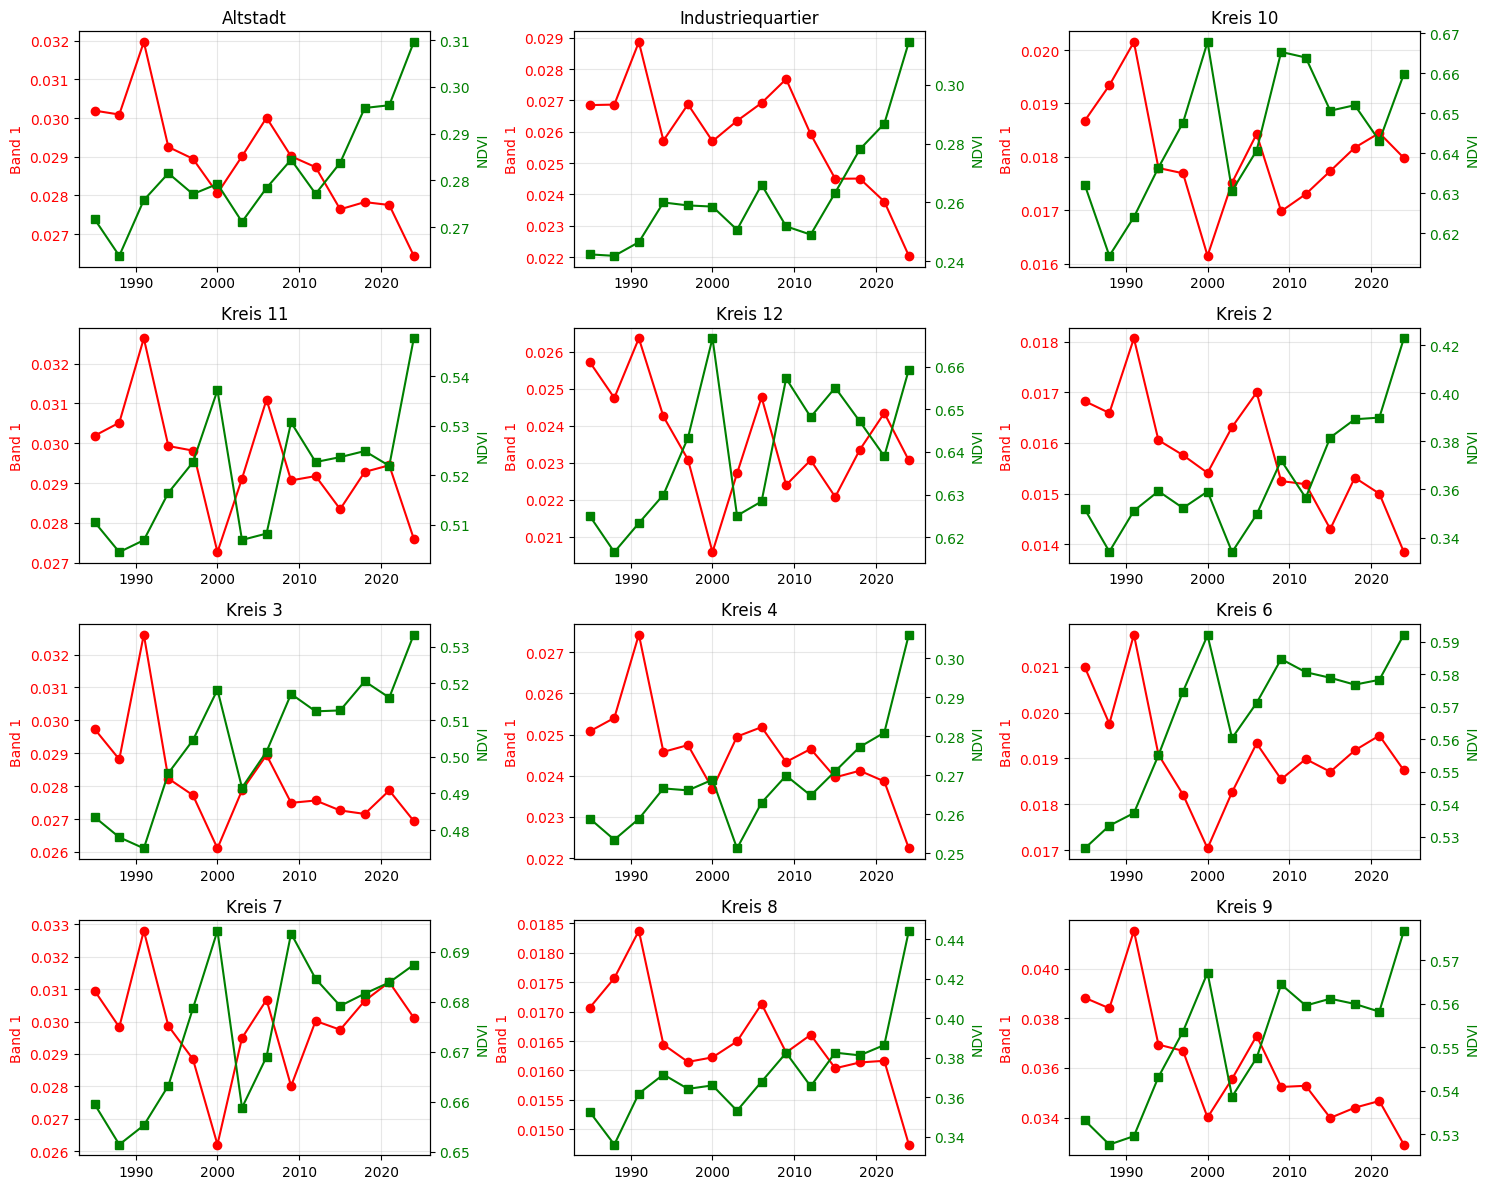

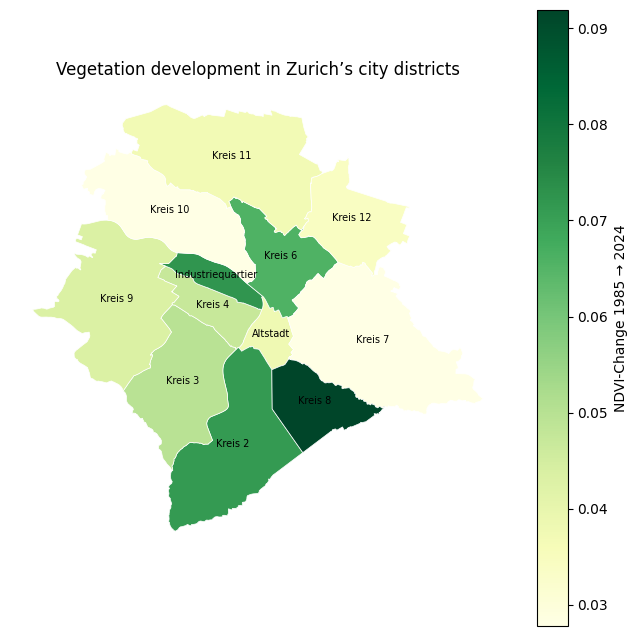

In [2]:


# 1. SETUP – Libraries, paths, helper functions

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
from rasterio.mask import mask
from rasterio.features import geometry_mask
import geopandas as gpd

from google.colab import drive
drive.mount('/content/drive')

# Configuration
BASE = Path("/content/drive/MyDrive/Landsat_Zurich")
FILE_PATTERN = "LandsatComposite_Zurich_*.tif"
RED_BAND = 3      # Band 3 = Red
NIR_BAND = 4      # Band 4 = Near Infrared
CRS_TARGET = "EPSG:2056"   # Swiss LV95

# Helping functions

def extract_year(filepath):
    match = re.search(r"(\d{4})", filepath.stem)
    return int(match.group(1)) if match else None


def calculate_ndvi(nir_band, red_band):
    with np.errstate(divide="ignore", invalid="ignore"):
        nir = nir_band.astype(float)
        red = red_band.astype(float)
        return (nir - red) / (nir + red + 1e-10)


def load_raster_stats(files):
    records = []
    for fp in files:
        year = extract_year(fp)
        if year is None:
            continue
        with rasterio.open(fp) as src:
            arr = src.read(1).astype(float)
            records.append({
                "year": year,
                "file": fp.name,
                "mean": float(np.nanmean(arr)),
                "median": float(np.nanmedian(arr)),
                "min": float(np.nanmin(arr)),
                "max": float(np.nanmax(arr)),
            })
    return pd.DataFrame(records).sort_values("year").reset_index(drop=True)


def load_ndvi_stats(files):
    records = []
    for fp in files:
        year = extract_year(fp)
        if year is None:
            continue
        with rasterio.open(fp) as src:
            red = src.read(RED_BAND).astype(float)
            nir = src.read(NIR_BAND).astype(float)
            ndvi = calculate_ndvi(nir, red)
            records.append({
                "year": year,
                "ndvi_mean": float(np.nanmean(ndvi)),
                "ndvi_median": float(np.nanmedian(ndvi)),
                "ndvi_min": float(np.nanmin(ndvi)),
                "ndvi_max": float(np.nanmax(ndvi)),
            })
    return pd.DataFrame(records).sort_values("year").reset_index(drop=True)

# load raster data
files = sorted(BASE.glob(FILE_PATTERN))
print(f"{len(files)} Raster-Data found.")

for fp in files[:3]:
    print(f"  - {fp.name}")
if len(files) > 3:
    print(f"  - ... and {len(files)-3} more")

    fp = files[0]
with rasterio.open(fp) as src:
    print(f"Datei:   {fp.name}")
    print(f"CRS:     {src.crs}")
    print(f"Bänder:  {src.count}")
    print(f"Shape:   {src.shape}")
    print(f"Bounds:  {src.bounds}")
    print()
    for i in range(1, src.count + 1):
        band = src.read(i).astype(float)
        print(f"Band {i}: min={np.nanmin(band):.4f}, "
              f"max={np.nanmax(band):.4f}, "
              f"mean={np.nanmean(band):.4f}")

# 3. Time series: LST (Volume 1) over 40 years

#calculation the average value from Volume 1 for each year.
#This value serves as an indicator of surface conditions.

df_lst = load_raster_stats(files)
df_lst

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_lst["year"], df_lst["mean"], marker="o", linewidth=2, color="red")
ax.set_title("Zurich: Average Grid Value (Band 1) 1985–2024")
ax.set_xlabel("year")
ax.set_ylabel("Mean Band 1")
ax.grid(True, alpha=0.3)
plt.show()

# Smoothed trend using a three-year moving average
df_lst["rolling_mean"] = df_lst["mean"].rolling(window=3, center=True).mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_lst["year"], df_lst["mean"], "o", alpha=0.4, label="Jahreswert")
ax.plot(df_lst["year"], df_lst["rolling_mean"], linewidth=3, label="Geglätteter Trend")
ax.set_title("Zurich time series with a smoothed trend")
ax.set_xlabel("year")
ax.set_ylabel("Mean Band 1")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# 4. NDVI time series

df_ndvi = load_ndvi_stats(files)
df_ndvi

# 5. Comparing LST and NDVI

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(df_lst["year"], df_lst["mean"], "o-", color="red", label="Band 1 (LST)")
ax1.set_ylabel("Band 1", color="red")
ax1.tick_params(axis="y", labelcolor="red")

ax2 = ax1.twinx()
ax2.plot(df_ndvi["year"], df_ndvi["ndvi_mean"], "s-", color="green", label="NDVI")
ax2.set_ylabel("NDVI", color="green")
ax2.tick_params(axis="y", labelcolor="green")

ax1.set_title("LST and NDVI in Zürich 1985–2024")
ax1.grid(True, alpha=0.3)
plt.show()

# Calculate correlation
combined = df_lst.merge(df_ndvi, on="year")
corr = combined["mean"].corr(combined["ndvi_mean"])
print(f"Pearson-Korrelation LST vs NDVI: r = {corr:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(combined["ndvi_mean"], combined["mean"],
                c=combined["year"], cmap="viridis")
ax.set_xlabel("NDVI (Mean)")
ax.set_ylabel("Band 1 (Mean)")
ax.set_title(f"Korrelation LST vs NDVI: r = {corr:.4f}")
ax.grid(True, alpha=0.3)
plt.colorbar(sc, label="Jahr")
plt.show()

# 6. Compare urban districts

#Determine whether certain neighbourhoods are warming faster than others.
#Load the Zurich city districts (districts 1–12) from OpenStreetMap and calculate the LST and NDVI trends for each district.

!pip install osmnx -q
import osmnx as ox

zurich = ox.geocode_to_gdf("Zürich, Switzerland")
kreise = ox.features_from_place("Zürich, Switzerland",
                                tags={"admin_level": "9"})
kreise = kreise[kreise.geometry.type.isin(["Polygon", "MultiPolygon"])]
kreise = kreise.to_crs(CRS_TARGET)

kreise[["name", "geometry"]].head(12)

def analyze_kreise(files, kreise):
    results = []

    for fp in files:
        year = extract_year(fp)
        if year is None:
            continue

        with rasterio.open(fp) as src:
            kreise_reproj = kreise.to_crs(src.crs)
            red = src.read(RED_BAND).astype(float)
            nir = src.read(NIR_BAND).astype(float)
            ndvi_arr = calculate_ndvi(nir, red)

            for _, row in kreise_reproj.iterrows():
                try:
                    out_lst, _ = mask(src, [row.geometry], crop=True)
                    lst_mean = float(np.nanmean(out_lst[0].astype(float)))

                    poly_mask = ~geometry_mask(
                        [row.geometry],
                        out_shape=red.shape,
                        transform=src.transform
                    )
                    ndvi_mean = float(np.nanmean(ndvi_arr[poly_mask]))

                    results.append({
                        "year": year,
                        "kreis": row.get("name", "unknown"),
                        "lst": lst_mean,
                        "ndvi": ndvi_mean,
                    })
                except Exception:
                    continue

    return pd.DataFrame(results)


df_kreise = analyze_kreise(files, kreise)
df_kreise.head(15)

# 7. Change by district: 1985 → 2024

pivot_lst = df_kreise.pivot_table(index="kreis", columns="year",
                                   values="lst")
pivot_ndvi = df_kreise.pivot_table(index="kreis", columns="year",
                                    values="ndvi")

vergleich = pd.DataFrame({
    "lst_1985": pivot_lst[1985],
    "lst_2024": pivot_lst[2024],
    "lst_change": pivot_lst[2024] - pivot_lst[1985],
    "ndvi_1985": pivot_ndvi[1985],
    "ndvi_2024": pivot_ndvi[2024],
    "ndvi_change": pivot_ndvi[2024] - pivot_ndvi[1985],
}).round(4).sort_values("lst_change")

vergleich


# 8. Districts detailed

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()

for i, kreis_name in enumerate(sorted(df_kreise["kreis"].unique())):
    data = df_kreise[df_kreise["kreis"] == kreis_name] \
        .sort_values("year")
    ax = axes[i]

    ax.plot(data["year"], data["lst"], "o-", color="red",
            label="Band 1")
    ax.set_ylabel("Band 1", color="red")
    ax.tick_params(axis="y", labelcolor="red")

    ax2 = ax.twinx()
    ax2.plot(data["year"], data["ndvi"], "s-", color="green",
             label="NDVI")
    ax2.set_ylabel("NDVI", color="green")
    ax2.tick_params(axis="y", labelcolor="green")

    ax.set_title(kreis_name)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Map of NDVI change

kreise_map = kreise.merge(
    vergleich[["ndvi_change"]],
    left_on="name",
    right_index=True,
    how="left",
)

fig, ax = plt.subplots(figsize=(8, 8))
kreise_map.plot(
    column="ndvi_change",
    cmap="YlGn",
    legend=True,
    ax=ax,
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={"label": "NDVI-Change 1985 → 2024"},
)
ax.set_title("Vegetation development in Zurich’s city districts")

for _, row in kreise_map.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        text=row.get("name", ""),
        xy=(centroid.x, centroid.y),
        ha="center",
        fontsize=7,
    )

ax.set_axis_off()
plt.show()



